# QPD readout from the Jaynes-Cummings Hamiltonian

This notebook builds the QPD dispersive-readout theory **starting from the
full qubit–resonator Hamiltonian**, numerically diagonalized in a truncated
joint Hilbert space. We compare it side-by-side against the perturbative
formula (Eqn. 3 of [Serniak et al., PRA 2019](https://arxiv.org/pdf/1903.00113))
already implemented in `qpd.compute_dispersive_matrix(method='perturbative')`,
and use it to extract multi-photon (AC Stark) effects that the perturbative
theory cannot give.

**Outline**

1. Recap: CPB Hamiltonian (matches the existing `qpd.ipynb`).
2. Perturbative dispersive theory (Eqn. 3 of Serniak): what it assumes.
3. Jaynes–Cummings Hamiltonian: full coupling, no dispersive expansion.
4. Joint-space construction, diagonalization, dressed-state labeling.
5. Convergence in qubit and photon truncation.
6. Side-by-side: perturbative vs JC across $g$.
7. Counter-rotating terms: RWA vs non-RWA.
8. Multi-photon AC Stark: $\chi_i(n)$ and qubit-frequency Stark shifts.


In [1]:
%matplotlib inline
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from qpd import QPD

# WashU design parameters (intermediate E_J/E_C regime)
qpd = QPD(e_j_hz=6.95e9, e_c_hz=0.695e9)
print(f"E_J = {qpd.e_j_hz/1e9:.3f} GHz, E_C = {qpd.e_c_hz/1e9:.3f} GHz")
print(f"E_J/E_C = {qpd.ej_ec_ratio:.2f}  (QPD regime: 10–20)")


E_J = 6.950 GHz, E_C = 0.695 GHz
E_J/E_C = 10.00  (QPD regime: 10–20)


## 1. Recap: Cooper-pair-box Hamiltonian

The bare qubit, in the charge basis $|n\rangle$ (Cooper pairs on the island),
is

$$
\hat{H}_{\mathrm{CPB}}=4 E_C\,(\hat n - n_g)^2 - \tfrac{E_J}{2}\bigl(|n\rangle\langle n+1|+\mathrm{h.c.}\bigr).
$$

Charge parity enters by shifting $n_g \to n_g + \tfrac{1}{2}$ for an odd
quasiparticle on the island. This is exactly what `qpd.solve_eigensystem`
diagonalizes; see `notebooks/qpd.ipynb` for the full derivation. We just
extract the qubit eigenfrequencies and the number operator at the operating
point we'll use later.


In [2]:
ng = 0.25            # operating offset charge (dimensionless, period 1)
parity = 'even'
n_qubit_show = 6

qubit_freqs_hz, n_qubit_mat = qpd._qubit_block_in_eigenbasis(
    ng, parity=parity, n_qubit=n_qubit_show, charge_cutoff=30,
)
print("Qubit eigenfrequencies (relative to ground), GHz:")
print(qubit_freqs_hz / 1e9)


Qubit eigenfrequencies (relative to ground), GHz:
[ 0.          5.39904392  9.67745967 13.40209653 18.56753516 25.35176472]


In [3]:
with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(3.6, 3))
    im = ax.imshow(np.abs(n_qubit_mat), origin='lower', cmap='magma')
    ax.set_xlabel(r'qubit eigenstate $|j\rangle$')
    ax.set_ylabel(r'qubit eigenstate $|i\rangle$')
    ax.set_title(r'$|\langle i|\hat n|j\rangle|$ at $n_g=0.25$, even parity')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


## 2. Perturbative theory: Serniak Eqn. 3

The coupling to a single linear readout mode is

$$
\hat H = \hat H_{\mathrm{CPB}} + \hbar\omega_r\,\hat a^\dagger\hat a
        + \hbar g\,\hat n\,(\hat a + \hat a^\dagger).
$$

In the **dispersive regime** $g \ll |\omega_{ij}-\omega_r|$, second-order
perturbation theory in $g$ gives the qubit-state- and parity-dependent
shift

$$
\boxed{\;
\chi_{i,p} = g^2 \sum_{j\neq i}
            \frac{2\,\omega_{ij,p}\,|\langle j,p|\hat n|i,p\rangle|^2}
                 {\omega_{ij,p}^2 - \omega_r^2}.
\;}\qquad(\text{Serniak Eqn.\ 3})
$$

This is **not** the rotating-wave result — the denominator
$\omega_{ij}^2-\omega_r^2 = (\omega_{ij}-\omega_r)(\omega_{ij}+\omega_r)$
keeps the counter-rotating contribution. But it is still only second order
in $g$, and it assumes a single photon in the resonator implicitly (the
shift is taken to be linear in photon number, $\hbar\chi_{i,p}\,\hat a^\dagger\hat a$
in the effective Hamiltonian).

It is the workhorse formula in `qpd.compute_dispersive_matrix(method='perturbative')`.


In [4]:
GHZ = 1e9
MHZ = 1e6

coupling_g_hz = 40e6
readout_freq_hz = 7.0e9
num_levels = 6

mat_pert, chi_pert = qpd.compute_dispersive_matrix(
    offset_charge=ng,
    coupling_g_hz=coupling_g_hz,
    readout_freq_hz=readout_freq_hz,
    num_levels=num_levels,
    parity=parity,
    method='perturbative',
)
print(f"Perturbative chi_i (MHz) for first {num_levels} levels at n_g={ng}:")
for i, chi in enumerate(chi_pert):
    print(f"  chi_{i} = {chi/MHZ:+.4f} MHz")


Perturbative chi_i (MHz) for first 6 levels at n_g=0.25:
  chi_0 = +0.4166 MHz
  chi_1 = -0.2144 MHz
  chi_2 = -0.2958 MHz
  chi_3 = -0.0312 MHz
  chi_4 = +0.0802 MHz
  chi_5 = +0.0226 MHz


## 3. The JC Hamiltonian, without the dispersive expansion

We keep the **same physical** Hamiltonian as Section 2 but we do **not**
expand in $g/|\Delta|$. Instead we:

1. Truncate the qubit to its lowest $N_q$ eigenstates of
   $\hat H_{\mathrm{CPB}}(n_g, p)$.
2. Truncate the resonator to $N_r$ photons (Fock dimension $N_r+1$).
3. Build the joint matrix

$$
H/h \;=\; \mathrm{diag}(\omega_{q,i})\otimes\mathbb{1}_r
         + \omega_r\,\mathbb{1}_q\otimes \hat a^\dagger\hat a
         + g\,\hat n_q \otimes (\hat a + \hat a^\dagger),
$$

  where $\hat n_q$ is the number operator **projected into the truncated
  qubit eigenbasis**, and $\hat a$ is the standard ladder operator in the
  Fock basis $\langle m|\hat a|m+1\rangle=\sqrt{m+1}$.
4. Diagonalize. The eigenstates are *dressed* states — we label each
   dressed state by the **bare** $|i,n\rangle$ with maximum overlap.

The rotating-wave approximation (RWA) corresponds to keeping only the
co-rotating part of $\hat n(\hat a+\hat a^\dagger)$, i.e. retaining
$\hat n^+\otimes \hat a + \hat n^-\otimes \hat a^\dagger$ where $\hat n^+$
is the upper-triangular (qubit-raising) part of $\hat n$ in the qubit
eigenbasis. The non-RWA Hamiltonian is what we use by default below.

This is implemented in:

- `qpd.build_jc_hamiltonian(...)` — assemble $H$ in Hz.
- `qpd.solve_jc_eigensystem(...)` — diagonalize and label dressed states.
- `qpd.compute_dispersive_matrix(..., method='jc')` — read $\chi_{i,p}$
   from the dressed spectrum:

$$
\chi_{i,p} \;=\; \frac{E(|i,1\rangle) - E(|i,0\rangle)}{h} - \omega_r.
$$

- `qpd.compute_stark_spectrum(...)` — full dressed map for multi-photon
   analysis (Section 8).


In [5]:
n_qubit = 8
n_photon = 5

H_jc, qfreqs, nmat, basis_labels = qpd.build_jc_hamiltonian(
    offset_charge=ng,
    coupling_g_hz=coupling_g_hz,
    readout_freq_hz=readout_freq_hz,
    parity=parity,
    n_qubit=n_qubit,
    n_photon=n_photon,
    rwa=False,
    return_components=True,
)
print(f"Joint Hilbert space: D = n_qubit * (n_photon+1) = {H_jc.shape[0]}")
print(f"H_jc returned in Hz.")


Joint Hilbert space: D = n_qubit * (n_photon+1) = 48
H_jc returned in Hz.


In [6]:
with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4, 3.6))
    # Plot |H| in GHz on log scale to see structure
    H_abs = np.abs(H_jc) / GHZ
    im = ax.imshow(np.log10(H_abs + 1e-6), origin='lower', cmap='magma')
    ax.set_title(r'$\log_{10}|H_{\mathrm{JC}}/h|$ [GHz]')
    ax.set_xlabel('joint basis index')
    ax.set_ylabel('joint basis index')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


### Diagonalization and dressed-state labeling

We diagonalize $H_{\mathrm{JC}}$ with `scipy.linalg.eigh` (it's real
symmetric — the coupling matrix $\hat n_q$ is real and so are the Fock
operators) and identify each dressed eigenstate with the bare $|i,n\rangle$
that has the largest probability $|\langle i,n|\psi\rangle|^2$. The same
overlap is reported — small overlap is a warning that we are near an
anticrossing where the labeling becomes ambiguous.


In [7]:
dressed_freqs, dressed_vecs, labels, overlaps = qpd.solve_jc_eigensystem(
    offset_charge=ng,
    coupling_g_hz=coupling_g_hz,
    readout_freq_hz=readout_freq_hz,
    parity=parity,
    n_qubit=n_qubit, n_photon=n_photon, rwa=False,
)

# Show the first few dressed states with their labels
print(f"{'idx':>3}  {'E [GHz]':>10}  {'bare (i,n)':>12}  {'overlap':>8}")
for k in range(min(12, len(dressed_freqs))):
    i, n = labels[k]
    print(f"{k:3d}  {dressed_freqs[k]/GHZ:10.4f}  {(i,n)!s:>12}  {overlaps[k]:8.3f}")

# Health check: smallest overlap
print(f"\nMin overlap across all dressed states: {overlaps.min():.3f}")
print("(values close to 1 indicate clean dispersive labeling)")


idx     E [GHz]    bare (i,n)   overlap
  0     -0.0001        (0, 0)     1.000
  1      5.3985        (1, 0)     1.000
  2      7.0004        (0, 1)     1.000
  3      9.6769        (2, 0)     1.000
  4     12.3982        (1, 1)     0.999
  5     13.4015        (3, 0)     1.000
  6     14.0008        (0, 2)     0.999
  7     16.6766        (2, 1)     1.000
  8     18.5665        (4, 0)     1.000
  9     19.3980        (1, 2)     0.999
 10     20.4015        (3, 1)     0.999
 11     21.0012        (0, 3)     0.999

Min overlap across all dressed states: 0.996
(values close to 1 indicate clean dispersive labeling)


## 4. Convergence in qubit and photon truncation

The truncations $N_q$ and $N_r$ are knobs. We check $\chi_{0}$ and $\chi_{1}$
converge as we raise them.


In [8]:
configs = [(4, 2), (6, 3), (8, 4), (10, 5), (12, 8), (14, 10)]
rows = []
for nq, npt in configs:
    _, chi = qpd.compute_dispersive_matrix(
        ng, coupling_g_hz, readout_freq_hz,
        num_levels=4, parity=parity,
        method='jc', n_qubit=nq, n_photon=npt,
    )
    rows.append((nq, npt, chi[0], chi[1], chi[2], chi[3]))

print(f"{'n_q':>4} {'n_ph':>5} {'chi_0':>10} {'chi_1':>10} {'chi_2':>10} {'chi_3':>10}  [MHz]")
for nq, npt, c0, c1, c2, c3 in rows:
    print(f"{nq:4d} {npt:5d} {c0/MHZ:10.5f} {c1/MHZ:10.5f} {c2/MHZ:10.5f} {c3/MHZ:10.5f}")


 n_q  n_ph      chi_0      chi_1      chi_2      chi_3  [MHz]
   4     2    0.41658   -0.21031   -0.18796   -0.01689
   6     3    0.41649   -0.21409   -0.29571   -0.03149
   8     4    0.41649   -0.21410   -0.29576   -0.03152
  10     5    0.41649   -0.21410   -0.29576   -0.03152
  12     8    0.41649   -0.21410   -0.29576   -0.03152
  14    10    0.41649   -0.21410   -0.29576   -0.03152


Defaults of `n_qubit=8`, `n_photon=5` already give ~6-digit agreement
with much larger truncations at this $g$. As $g$ grows, more photon levels
are needed (the dressed states acquire more bare-Fock content).


## 5. Side-by-side: perturbative vs JC across $g$

In the small-$g$ limit, the JC result must reproduce Eqn. 3 of Serniak
(both keep counter-rotating terms; JC just goes to higher order in $g$ via
the dressed diagonalization). At larger $g$, the two diverge in a
well-defined way.


In [9]:
g_list_mhz = np.array([1, 5, 10, 20, 40, 80, 150, 250, 400])
chi0_pert = np.empty_like(g_list_mhz, dtype=float)
chi0_jc = np.empty_like(g_list_mhz, dtype=float)
chi1_pert = np.empty_like(g_list_mhz, dtype=float)
chi1_jc = np.empty_like(g_list_mhz, dtype=float)

for k, g_mhz in enumerate(g_list_mhz):
    _, chi_p = qpd.compute_dispersive_matrix(
        ng, g_mhz*MHZ, readout_freq_hz, num_levels=4, parity=parity,
        method='perturbative',
    )
    _, chi_j = qpd.compute_dispersive_matrix(
        ng, g_mhz*MHZ, readout_freq_hz, num_levels=4, parity=parity,
        method='jc', n_qubit=12, n_photon=8,
    )
    chi0_pert[k] = chi_p[0]
    chi0_jc[k] = chi_j[0]
    chi1_pert[k] = chi_p[1]
    chi1_jc[k] = chi_j[1]


In [10]:
with plt.style.context(QPD._style_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3))

    ax1.loglog(g_list_mhz, np.abs(chi0_pert)/MHZ, 'o-', label=r'$|\chi_0|$ pert.')
    ax1.loglog(g_list_mhz, np.abs(chi0_jc)/MHZ, 's--', label=r'$|\chi_0|$ JC')
    ax1.loglog(g_list_mhz, np.abs(chi1_pert)/MHZ, 'o-', label=r'$|\chi_1|$ pert.')
    ax1.loglog(g_list_mhz, np.abs(chi1_jc)/MHZ, 's--', label=r'$|\chi_1|$ JC')
    ax1.set_xlabel(r'$g$ [MHz]')
    ax1.set_ylabel(r'$|\chi_i|$ [MHz]')
    ax1.legend(fontsize=7)
    ax1.grid(alpha=0.3, which='both')

    rel0 = np.abs((chi0_jc - chi0_pert) / chi0_pert)
    rel1 = np.abs((chi1_jc - chi1_pert) / chi1_pert)
    ax2.loglog(g_list_mhz, rel0, 'o-', label=r'$\chi_0$')
    ax2.loglog(g_list_mhz, rel1, 's-', label=r'$\chi_1$')
    # Reference slope-2 (next-order PT in g) and slope-4 lines
    ax2.loglog(g_list_mhz, 1e-6*g_list_mhz**2, 'k--', alpha=0.5, label=r'$\propto g^2$')
    ax2.set_xlabel(r'$g$ [MHz]')
    ax2.set_ylabel(r'$|\chi_\mathrm{JC} - \chi_\mathrm{pert}|/|\chi_\mathrm{pert}|$')
    ax2.legend(fontsize=7)
    ax2.grid(alpha=0.3, which='both')
    fig.suptitle(f'$n_g={ng}$, parity={parity}, $f_r={readout_freq_hz/GHZ:.1f}$ GHz', fontsize=9)


**Reading the right panel.** The relative deviation grows like $g^2$
(power-counting: the next term beyond the second-order PT is $\mathcal{O}(g^4)$
in $\chi$, which is $\mathcal{O}(g^2)$ relative to $\chi\sim g^2$). At
$g\lesssim 40$ MHz (typical) the two theories agree to ~1%; at $g \gtrsim 200$
MHz the perturbative formula is no longer trustworthy and JC is the right
tool.


### $\chi$ vs offset charge: side-by-side curves


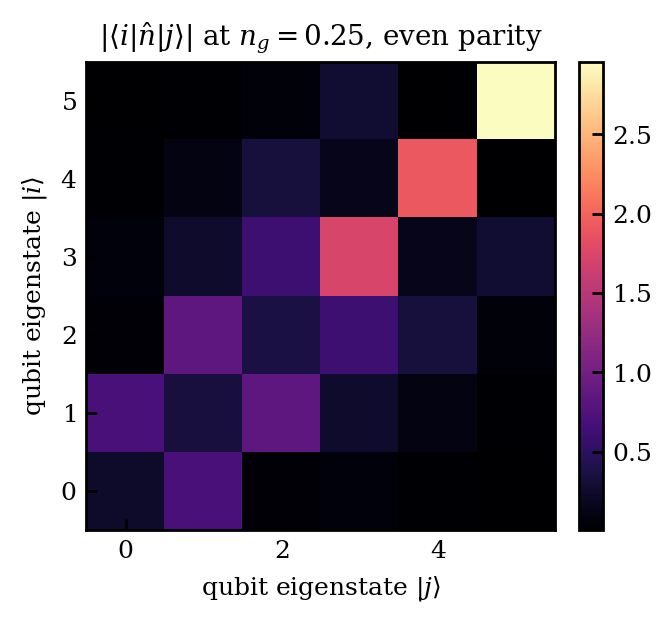

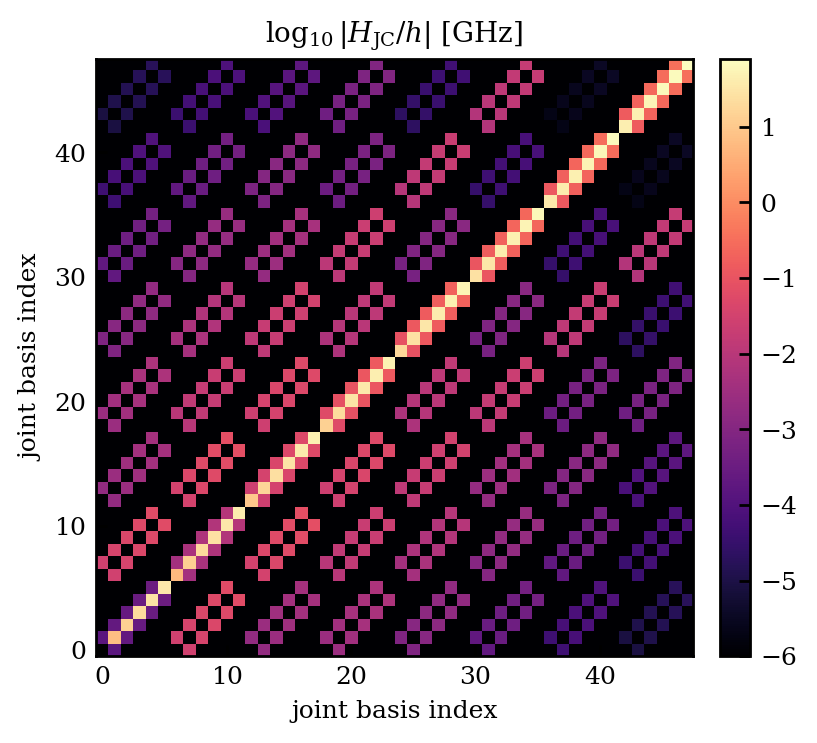

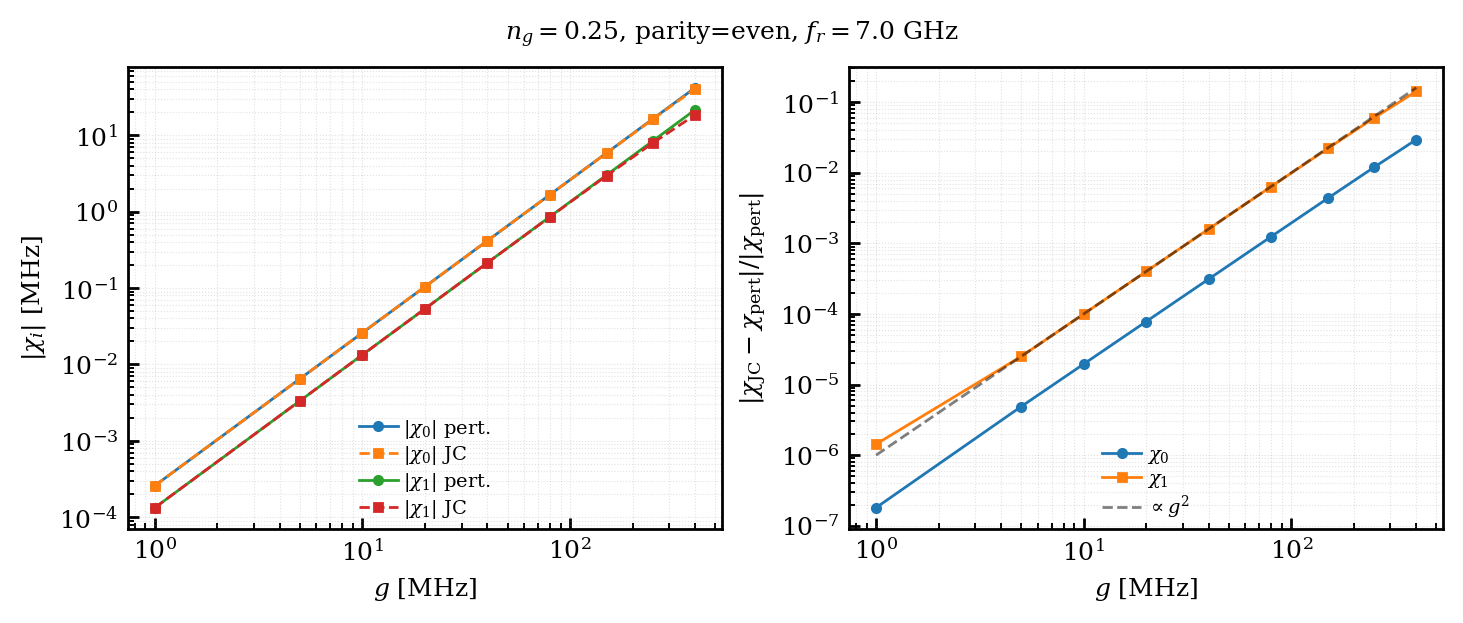

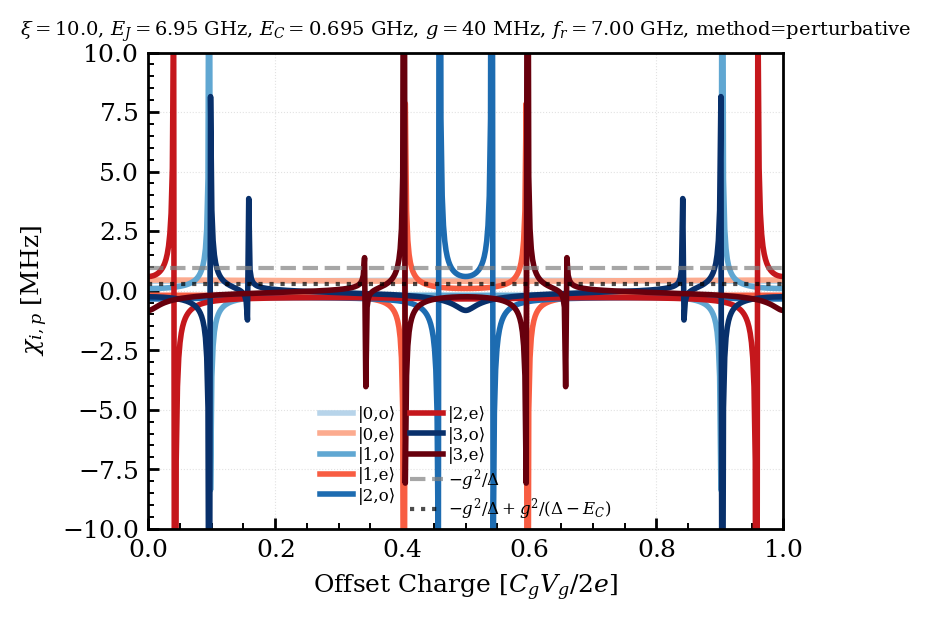

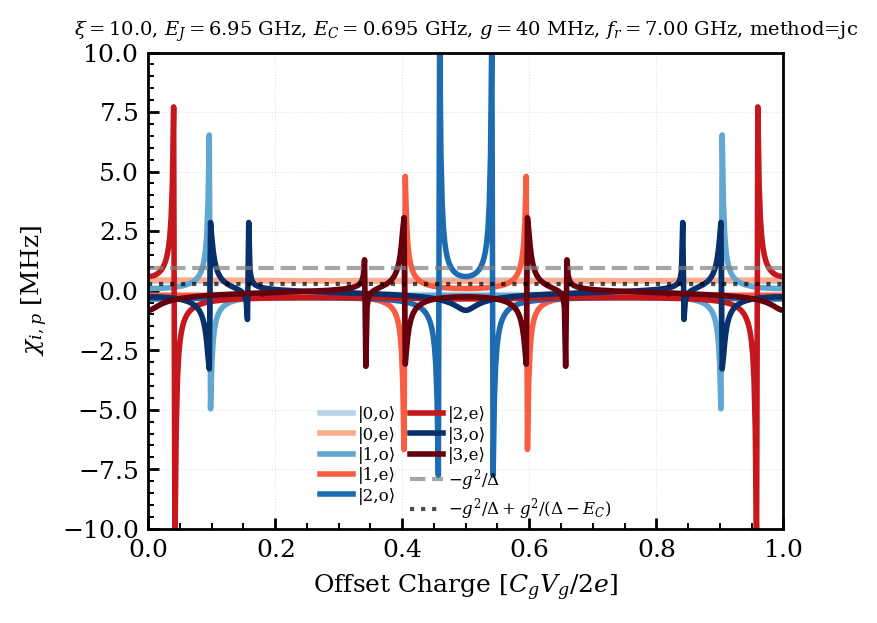

In [11]:
# Use built-in plotter, dispatching on method=
fig_p, ax_p = qpd.plot_dispersive_shift(
    coupling_g_hz=40e6, readout_freq_hz=7e9,
    method='perturbative',
)
fig_j, ax_j = qpd.plot_dispersive_shift(
    coupling_g_hz=40e6, readout_freq_hz=7e9,
    method='jc', n_qubit=10, n_photon=5,
)
plt.show()


## 6. Counter-rotating terms: full vs RWA

Eqn. 3 of Serniak is **not** an RWA result — it keeps both
$\omega_{ij}-\omega_r$ and $\omega_{ij}+\omega_r$ in the denominator. To
see this explicitly we compare:

- `method='jc'`, `rwa=False` (default) — full $\hat n(\hat a+\hat a^\dagger)$;
  reduces to Eqn. 3 in the $g\to 0$ limit.
- `method='jc'`, `rwa=True` — drops the counter-rotating
  $\hat n^+ \hat a^\dagger + \hat n^- \hat a$ terms; this corresponds to
  the Jaynes–Cummings model proper. It misses the Bloch–Siegert shift
  $\sim g^2/(\omega_{ij}+\omega_r)$, which for QPD with $\omega_{01}\sim 6$
  GHz and $\omega_r\sim 7$ GHz is comparable in size to the resonant
  contribution.


In [12]:
_, chi_p = qpd.compute_dispersive_matrix(
    ng, 40e6, 7e9, num_levels=4, parity=parity,
    method='perturbative')
_, chi_jc_full = qpd.compute_dispersive_matrix(
    ng, 40e6, 7e9, num_levels=4, parity=parity,
    method='jc', n_qubit=10, n_photon=5, rwa=False)
_, chi_jc_rwa = qpd.compute_dispersive_matrix(
    ng, 40e6, 7e9, num_levels=4, parity=parity,
    method='jc', n_qubit=10, n_photon=5, rwa=True)

print("chi_i in MHz (i=0..3):")
print(f"  Serniak Eqn.3  : {chi_p[:4]/MHZ}")
print(f"  JC full (no RWA): {chi_jc_full[:4]/MHZ}")
print(f"  JC + RWA       : {chi_jc_rwa[:4]/MHZ}")
print()
print("Bloch-Siegert-like piece (full − RWA), MHz:")
print(f"  {(chi_jc_full - chi_jc_rwa)[:4] / MHZ}")


chi_i in MHz (i=0..3):
  Serniak Eqn.3  : [ 0.41661866 -0.21444015 -0.29579395 -0.03117823]
  JC full (no RWA): [ 0.4164886  -0.21409749 -0.2957592  -0.03151633]
  JC + RWA       : [-0.06282956 -0.04593424  0.03369772  0.05307144]

Bloch-Siegert-like piece (full − RWA), MHz:
  [ 0.47931816 -0.16816325 -0.32945692 -0.08458777]


## 7. Multi-photon AC Stark shifts

The JC diagonalization gives us the **entire** dressed spectrum $E(|i,n\rangle)$,
not just the single-photon dispersive shift. We expose two photon-number-resolved
quantities via `qpd.compute_stark_spectrum`:

- **Photon-number-dependent dispersive shift**

  $$ \chi_i(n) \;=\; \bigl[E(|i,n+1\rangle) - E(|i,n\rangle)\bigr] - \omega_r,$$

  i.e. the resonator transition frequency from $n$ to $n+1$ photons when
  the qubit sits in dressed $|i\rangle$. For $n=0$ this matches the
  single-photon $\chi_{i,p}$ above.

- **AC Stark shift on qubit transitions**

  $$ \Delta\omega_{0i}(n) \;=\; [E(|i,n\rangle)-E(|0,n\rangle)] - [E(|i,0\rangle)-E(|0,0\rangle)],$$

  i.e. how much the qubit $|0\rangle\to|i\rangle$ transition shifts when the
  resonator is populated with $n$ photons.

Neither is accessible from Eqn. 3 directly — it assumed the resonator
appears only in the $\hat a^\dagger\hat a$ form, i.e. it linearized the
photon-number dependence by construction.


In [13]:
g_test = 80e6  # large coupling makes effects visible

dressed, chi_n, qubit_stark = qpd.compute_stark_spectrum(
    offset_charge=ng,
    coupling_g_hz=g_test,
    readout_freq_hz=readout_freq_hz,
    num_levels=4,
    parity=parity,
    n_qubit=15, n_photon=15, rwa=False,
)
print(f"chi_n shape: {chi_n.shape}  (levels × n_photon)")
print(f"qubit_stark shape: {qubit_stark.shape}  (levels × (n_photon+1))")


chi_n shape: (4, 15)  (levels × n_photon)
qubit_stark shape: (4, 16)  (levels × (n_photon+1))


/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_37492/3357930731.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


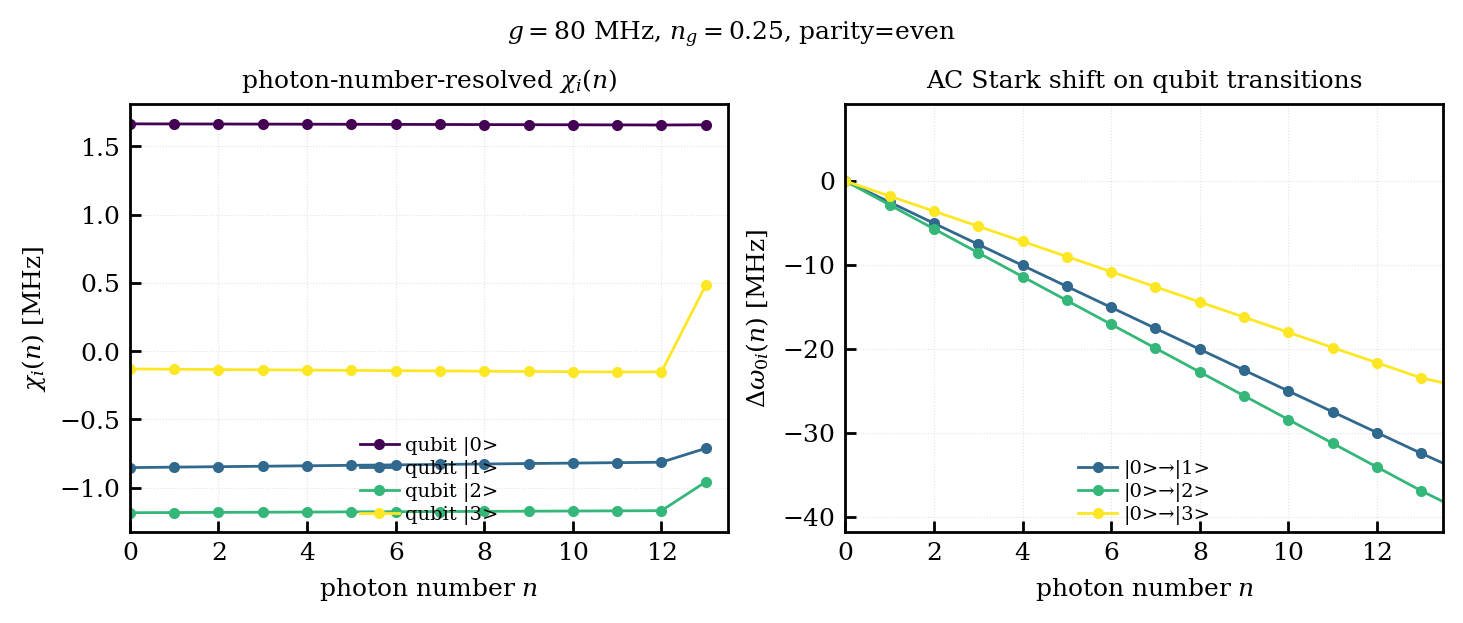

In [14]:
# Drop the topmost photon column for chi_n — it is asymmetrically dressed
# at the Fock truncation edge and not physical
n_safe = chi_n.shape[1] - 1
photons = np.arange(n_safe)

with plt.style.context(QPD._style_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3))

    cmap = cm.get_cmap('viridis')
    for i in range(chi_n.shape[0]):
        ax1.plot(photons, chi_n[i, :n_safe]/MHZ, 'o-',
                 color=cmap(i / max(chi_n.shape[0]-1, 1)),
                 label=f'qubit |{i}>')
    ax1.set_xlabel('photon number $n$')
    ax1.set_ylabel(r'$\chi_i(n)$ [MHz]')
    ax1.legend(fontsize=7)
    ax1.grid(alpha=0.3)
    ax1.set_xlim(0, 13.5)
    ax1.set_title(r'photon-number-resolved $\chi_i(n)$', fontsize=9)

    for i in range(1, qubit_stark.shape[0]):
        ax2.plot(np.arange(qubit_stark.shape[1]),
                 qubit_stark[i] / MHZ, 'o-',
                 color=cmap(i / max(qubit_stark.shape[0]-1, 1)),
                 label=f'|0>→|{i}>')
    ax2.set_xlim(0, 13.5)
    ax2.set_xlabel('photon number $n$')
    ax2.set_ylabel(r'$\Delta\omega_{0i}(n)$ [MHz]')
    ax2.legend(fontsize=7)
    ax2.grid(alpha=0.3)
    ax2.set_title('AC Stark shift on qubit transitions', fontsize=9)
    fig.suptitle(f'$g={g_test/MHZ:.0f}$ MHz, $n_g={ng}$, parity={parity}', fontsize=9)
plt.show()


**Interpretation.** The slope $\partial\chi_i/\partial n$ is the
**Kerr** (photon-photon) nonlinearity inherited from qubit-induced
anharmonicity of the dressed resonator. The AC Stark slope
$\partial \Delta\omega_{0i}/\partial n$ is the textbook Stark shift
$2\chi$ to leading order, but here it includes higher-order corrections
that come from the full diagonalization.


## 8. When the perturbative formula breaks down

Two practical signals that Eqn. 3 is no longer reliable, both visible
straight from the JC diagonalization:

1. **Dressed-state overlap drops well below 1.** Near a qubit–resonator
   anticrossing the labeling becomes ambiguous — that is exactly the
   physical regime where perturbation theory diverges.
2. **$|\chi_\mathrm{JC} - \chi_\mathrm{pert}|/|\chi_\mathrm{pert}|$ is no
   longer small** at the operating $g$.

The cell below sweeps the resonator frequency through the qubit
transitions and shows where dressed-state overlaps collapse.


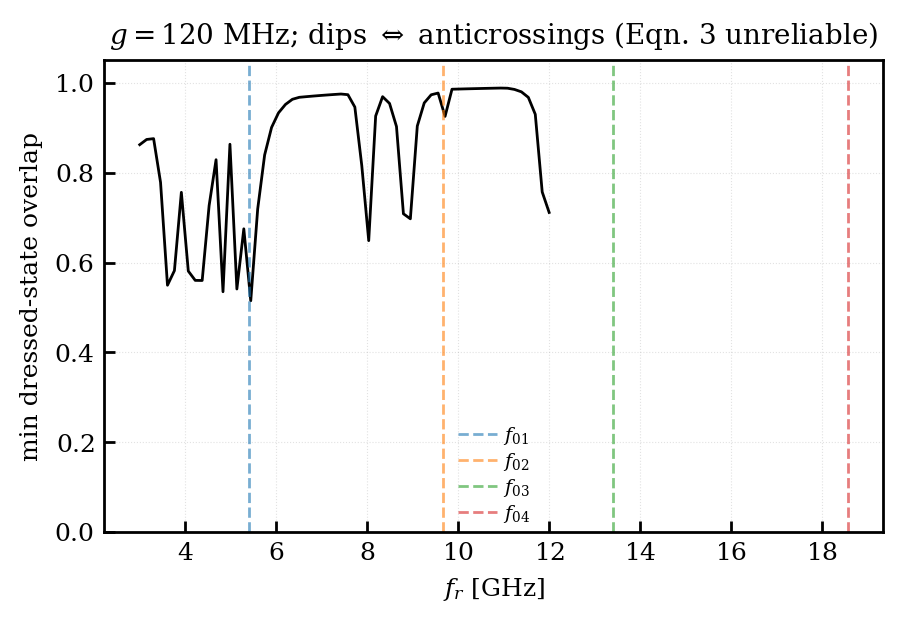

In [15]:
f_r_scan = np.linspace(3e9, 12e9, 60)
min_overlap = []
for f_r in f_r_scan:
    _, _, _, ov = qpd.solve_jc_eigensystem(
        ng, coupling_g_hz=120e6, readout_freq_hz=f_r,
        parity=parity, n_qubit=8, n_photon=4, rwa=False,
    )
    min_overlap.append(ov.min())

# Mark qubit transition frequencies
qfreqs, _ = qpd._qubit_block_in_eigenbasis(ng, parity=parity, n_qubit=5)
f_qubit = qfreqs[1:] - qfreqs[0]

with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4.4, 3))
    ax.plot(f_r_scan/GHZ, min_overlap, 'k-')
    for k, f_q in enumerate(f_qubit):
        ax.axvline(f_q/GHZ, color=f'C{k}', linestyle='--', alpha=0.6,
                   label=fr'$f_{{0{k+1}}}$')
    ax.set_xlabel(r'$f_r$ [GHz]')
    ax.set_ylabel('min dressed-state overlap')
    ax.set_title(r'$g=120$ MHz; dips $\Leftrightarrow$ anticrossings (Eqn. 3 unreliable)')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
plt.show()


## 9. Parity contrast vs offset charge, photon-number-resolved

A device-design question Eqn. 3 cannot answer: *how does the parity-readout
contrast $|\chi_{0,o} - \chi_{0,e}|$ change as we drive more photons into
the resonator?* The single-photon answer ($n=0$) is what the perturbative
formula returns; the JC diagonalization gives us $\chi_0(n)$ separately
for each photon number through `compute_stark_spectrum`. We can then ask
whether higher photon population enhances or suppresses the parity contrast
— and at which $n_g$.

We sweep $n_g$ over one period at a fixed resonator frequency
$f_r=6.936$ GHz (WashU device; configurable below) and plot one curve per
photon number, with colour mapped by $n$ (magma).


In [16]:
# --- configurable inputs ---
RESONATOR_FREQ_HZ = 6.936e9         # WashU resonator (change to your device)
COUPLING_G_HZ_S9 = 40e6             # WashU readout coupling (matches qpd.ipynb)
N_QUBIT_S9 = 15
N_PHOTON_S9 = 280                    # we'll trust photon indices < N_PHOTON_S9
N_NG = 201

ng_grid = np.linspace(0, 1, N_NG)
chi0_even = np.zeros((N_NG, N_PHOTON_S9))
chi0_odd  = np.zeros((N_NG, N_PHOTON_S9))

for k, ng_val in tqdm(enumerate(ng_grid)):   
    _, cn_e, _ = qpd.compute_stark_spectrum(
        offset_charge=ng_val,
        coupling_g_hz=COUPLING_G_HZ_S9,
        readout_freq_hz=RESONATOR_FREQ_HZ,
        num_levels=1, parity='even',
        n_qubit=N_QUBIT_S9, n_photon=N_PHOTON_S9, rwa=False,
        charge_cutoff=31
    )
    _, cn_o, _ = qpd.compute_stark_spectrum(
        offset_charge=ng_val,
        coupling_g_hz=COUPLING_G_HZ_S9,
        readout_freq_hz=RESONATOR_FREQ_HZ,
        num_levels=1, parity='odd',
        n_qubit=N_QUBIT_S9, n_photon=N_PHOTON_S9, rwa=False,
        charge_cutoff=31
    )
    chi0_even[k] = cn_e[0]  # i=0 (qubit ground), all photon-number transitions
    chi0_odd[k]  = cn_o[0]

dchi0 = chi0_odd - chi0_even  # (N_NG, N_PHOTON_S9)
print(f"computed chi_0,o - chi_0,e at f_r={RESONATOR_FREQ_HZ/GHZ:.3f} GHz, "
      f"g={COUPLING_G_HZ_S9/MHZ:.0f} MHz over {N_NG} n_g points and "
      f"{N_PHOTON_S9} photon-number bins.")


201it [2:53:13, 51.71s/it]

computed chi_0,o - chi_0,e at f_r=6.936 GHz, g=40 MHz over 201 n_g points and 280 photon-number bins.


/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_37492/1330908902.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('magma')


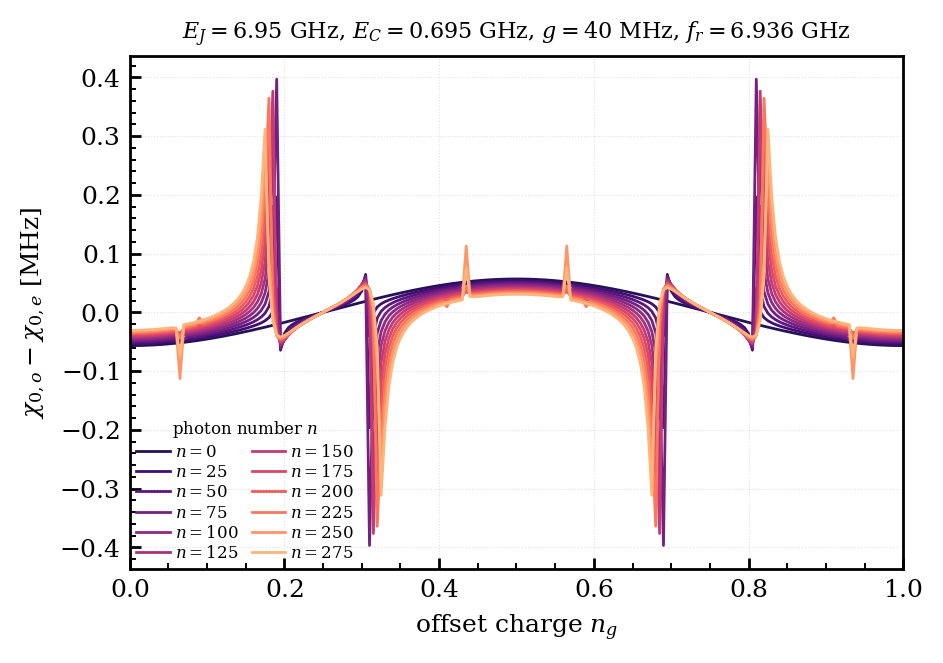

In [21]:
# Drop the topmost photon column — it is dressed against the Fock truncation
# edge and is not physical.
n_max_safe = N_PHOTON_S9 - 1
photons_to_plot = np.arange(n_max_safe)

with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4.6, 3.2))
    cmap = cm.get_cmap('magma')
    for n in photons_to_plot[::25]:
        # avoid the very darkest end of magma so n=0 stays visible
        color = cmap(0.15 + 0.7 * n / max(n_max_safe - 1, 1))
        ax.plot(ng_grid, dchi0[:, n] / MHZ,
                color=color, linewidth=1, label=f'$n={n}$')

    ax.set_xlim(0, 1)
    ax.set_xlabel(r'offset charge $n_g$')
    ax.set_ylabel(r'$\chi_{0,o} - \chi_{0,e}$ [MHz]')
    title_parts = [
        f'$E_J={qpd.e_j_hz/GHZ:.2f}$ GHz',
        f'$E_C={qpd.e_c_hz/GHZ:.3f}$ GHz',
        f'$g={COUPLING_G_HZ_S9/MHZ:.0f}$ MHz',
        f'$f_r={RESONATOR_FREQ_HZ/GHZ:.3f}$ GHz',
    ]
    ax.set_title(', '.join(title_parts), fontsize=8)
    ax.minorticks_on()
    ax.grid(alpha=0.3)
    ax.legend(loc='best', ncol=2, fontsize=6, title='photon number $n$',
              title_fontsize=6)
plt.show()


## Summary

| API | Theory | Notes |
|---|---|---|
| `qpd.compute_dispersive_matrix(..., method='perturbative')` | Serniak Eqn. 3 | Default; 2nd-order PT, full coupling (no RWA), single-photon $\chi$. |
| `qpd.compute_dispersive_matrix(..., method='jc')` | Numerical JC diagonalization | Captures higher-order and Bloch–Siegert effects. Toggle `rwa=True` to recover the Jaynes–Cummings RWA. |
| `qpd.compute_stark_spectrum(...)` | Numerical JC | Returns full dressed map $E(|i,n\rangle)$; photon-number-resolved $\chi_i(n)$ and AC Stark on qubit transitions. |
| `qpd.build_jc_hamiltonian`, `qpd.solve_jc_eigensystem` | Numerical JC | Low-level building blocks. |

Plotters `plot_dispersive_shift`, `plot_parity_shift_vs_ng`,
`plot_parity_shift_vs_frequency` all accept the same `method=` /
`n_qubit=` / `n_photon=` / `rwa=` switches.
